### DS605: Fundamentals of Machine Learning — Lab Assignment 3
### Scikit-learn: Data Preprocessing and Model Performance Evaluation


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, ConfusionMatrixDisplay)

pd.set_option('display.max_columns', None)
plt.rcParams['figure.figsize'] = (7, 5)
sns.set_style('whitegrid')

RANDOM_STATE = 42

#### Part A - Data Loading and Preprocessing
#### Task 1 - Load and Understand the Dataset

In [3]:
df = pd.read_csv('hotel_bookings.csv')
print("Shape:", df.shape)
df.head()

Shape: (119390, 32)


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [5]:
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


In [6]:
df.dtypes

hotel                              object
is_canceled                         int64
lead_time                           int64
arrival_date_year                   int64
arrival_date_month                 object
arrival_date_week_number            int64
arrival_date_day_of_month           int64
stays_in_weekend_nights             int64
stays_in_week_nights                int64
adults                              int64
children                          float64
babies                              int64
meal                               object
country                            object
market_segment                     object
distribution_channel               object
is_repeated_guest                   int64
previous_cancellations              int64
previous_bookings_not_canceled      int64
reserved_room_type                 object
assigned_room_type                 object
booking_changes                     int64
deposit_type                       object
agent                             

is_canceled
0    75166
1    44224
Name: count, dtype: int64

is_canceled
0    63.0
1    37.0
Name: proportion, dtype: float64 %


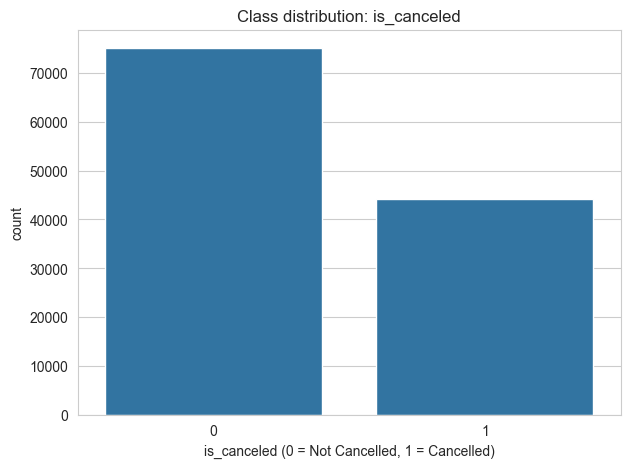

In [7]:
# Class distribution of the target variable
print(df['is_canceled'].value_counts())
print()
print(df['is_canceled'].value_counts(normalize=True).round(3) * 100, "%")

sns.countplot(x='is_canceled', data=df)
plt.title('Class distribution: is_canceled')
plt.xlabel('is_canceled (0 = Not Cancelled, 1 = Cancelled)')
plt.show()

In [8]:
# Separate target and features
y = df['is_canceled']
X_full = df.drop(columns=['is_canceled'])

numerical_cols = X_full.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X_full.select_dtypes(include=['object']).columns.tolist()

print("Numerical columns (%d):" % len(numerical_cols), numerical_cols)
print()
print("Categorical columns (%d):" % len(categorical_cols), categorical_cols)

Numerical columns (19): ['lead_time', 'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'agent', 'company', 'days_in_waiting_list', 'adr', 'required_car_parking_spaces', 'total_of_special_requests']

Categorical columns (12): ['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type', 'reservation_status', 'reservation_status_date']


#### Task 2 - Missing Values, Leakage, and Outliers

In [9]:
# Missing value count and percentage for every column
missing_count = df.isnull().sum()
missing_pct = (missing_count / len(df) * 100).round(2)
missing_summary = pd.DataFrame({'missing_count': missing_count, 'missing_pct': missing_pct})
missing_summary = missing_summary[missing_summary['missing_count'] > 0].sort_values('missing_pct', ascending=False)
missing_summary

,missing_count,missing_pct
company,112593,94.31
agent,16340,13.69
country,488,0.41
children,4,0.00


In [10]:
# Drop company (very high missingness), fill agent's missing with 0 (no agent used)
df = df.drop(columns=['company'])
df['agent'] = df['agent'].fillna(0)

# Update column lists
numerical_cols = [c for c in numerical_cols if c != 'company']
if 'agent' not in numerical_cols:
    numerical_cols.append('agent')
print("company dropped. agent missing filled with 0.")
print("Remaining missing values:\n", df.isnull().sum()[df.isnull().sum() > 0])

company dropped. agent missing filled with 0.
Remaining missing values:
 children      4
country     488
dtype: int64


In [11]:
# Remove leakage columns: these directly reveal the final booking outcome
leakage_cols = ['reservation_status', 'reservation_status_date']
df = df.drop(columns=leakage_cols)

numerical_cols = [c for c in numerical_cols if c not in leakage_cols]
categorical_cols = [c for c in categorical_cols if c not in leakage_cols]

print("Dropped leakage columns:", leakage_cols)
print("New shape:", df.shape)

Dropped leakage columns: ['reservation_status', 'reservation_status_date']
New shape: (119390, 29)


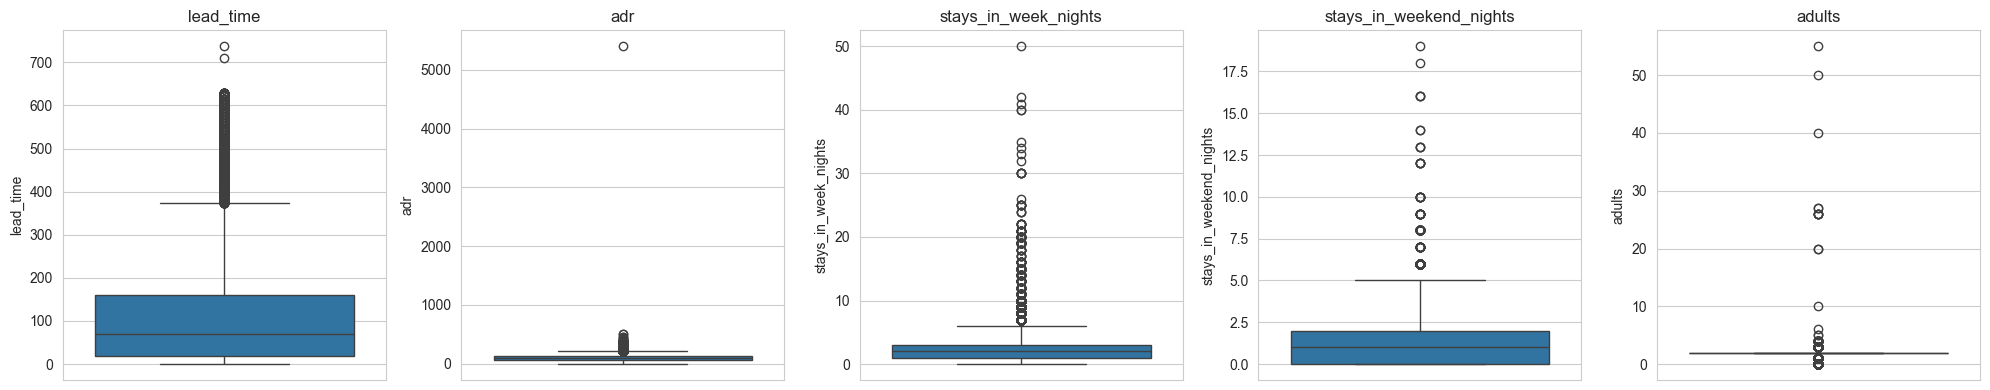

In [12]:
# Outlier check via boxplots for a few key numerical features
outlier_check_cols = ['lead_time', 'adr', 'stays_in_week_nights', 'stays_in_weekend_nights', 'adults']

fig, axes = plt.subplots(1, len(outlier_check_cols), figsize=(20, 4))
for ax, col in zip(axes, outlier_check_cols):
    sns.boxplot(y=df[col], ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

In [13]:
# IQR-based outlier detection and removal for the most extreme cases
def iqr_bounds(series, k=1.5):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    return q1 - k * iqr, q3 + k * iqr

rows_before = len(df)

# adr: remove clearly invalid / extreme values (negative or absurdly high)
low, high = iqr_bounds(df['adr'], k=3)  # k=3 -> only the most extreme outliers
df = df[(df['adr'] >= max(0, low)) & (df['adr'] <= high)]

# lead_time: remove extreme outliers only (k=3, conservative)
low, high = iqr_bounds(df['lead_time'], k=3)
df = df[(df['lead_time'] >= low) & (df['lead_time'] <= high)]

# adults: a booking with 0 adults or an unrealistic number of adults is a data error
df = df[(df['adults'] > 0) & (df['adults'] <= 10)]

rows_after = len(df)
print(f"Rows before outlier removal: {rows_before}")
print(f"Rows after outlier removal:  {rows_after}")
print(f"Rows removed: {rows_before - rows_after} ({(rows_before - rows_after) / rows_before * 100:.2f}%)")

Rows before outlier removal: 119390
Rows after outlier removal:  118483
Rows removed: 907 (0.76%)


In [14]:
# Rebuild X, y after cleaning
y = df['is_canceled']
X = df.drop(columns=['is_canceled'])

numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()

print("Final feature set -> numerical: %d, categorical: %d" % (len(numerical_cols), len(categorical_cols)))
print("Final X shape:", X.shape)

Final feature set -> numerical: 18, categorical: 10
Final X shape: (118483, 28)


#### Task 3 - Create Two Preprocessing Pipelines

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print("Train shape:", X_train.shape, " Test shape:", X_test.shape)

Train shape: (94786, 28)  Test shape: (23697, 28)


In [16]:
# Categorical transformer: shared by both pipelines
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Pipeline A: KNNImputer + StandardScaler for numerical features
numerical_transformer_A = Pipeline(steps=[
    ('imputer', KNNImputer(n_neighbors=5)),
    ('scaler', StandardScaler())
])

preprocessor_A = ColumnTransformer(transformers=[
    ('num', numerical_transformer_A, numerical_cols),
    ('cat', categorical_transformer, categorical_cols)
])

# Pipeline B: KNNImputer + MinMaxScaler for numerical features
numerical_transformer_B = Pipeline(steps=[
    ('imputer', KNNImputer(n_neighbors=5)),
    ('scaler', MinMaxScaler())
])

preprocessor_B = ColumnTransformer(transformers=[
    ('num', numerical_transformer_B, numerical_cols),
    ('cat', categorical_transformer, categorical_cols)
])

print("Pipeline A (StandardScaler) and Pipeline B (MinMaxScaler) defined.")
print("Both fitted only on training data via ColumnTransformer + Pipeline.")

Pipeline A (StandardScaler) and Pipeline B (MinMaxScaler) defined.
Both fitted only on training data via ColumnTransformer + Pipeline.


#### Part B - Model Training and Performance Evaluation

#### Task 4 - Train Two Classification Models

In [17]:
def build_and_train(preprocessor, model):
    clf = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    clf.fit(X_train, y_train)
    return clf

# Four model-pipeline combinations
logreg_A = build_and_train(preprocessor_A, LogisticRegression(max_iter=1000))
logreg_B = build_and_train(preprocessor_B, LogisticRegression(max_iter=1000))
tree_A   = build_and_train(preprocessor_A, DecisionTreeClassifier(random_state=42))
tree_B   = build_and_train(preprocessor_B, DecisionTreeClassifier(random_state=42))

print("All four model-pipeline combinations trained:")
print("1. Logistic Regression + Pipeline A (StandardScaler)")
print("2. Logistic Regression + Pipeline B (MinMaxScaler)")
print("3. Decision Tree + Pipeline A (StandardScaler)")
print("4. Decision Tree + Pipeline B (MinMaxScaler)")

All four model-pipeline combinations trained:
1. Logistic Regression + Pipeline A (StandardScaler)
2. Logistic Regression + Pipeline B (MinMaxScaler)
3. Decision Tree + Pipeline A (StandardScaler)
4. Decision Tree + Pipeline B (MinMaxScaler)


#### Task 5 - Evaluate and Compare the Four Results

In [18]:
def evaluate(clf, name):
    train_pred = clf.predict(X_train)
    test_pred = clf.predict(X_test)

    return {
        'Model': name,
        'Train Accuracy': accuracy_score(y_train, train_pred),
        'Test Accuracy': accuracy_score(y_test, test_pred),
        'Precision': precision_score(y_test, test_pred),
        'Recall': recall_score(y_test, test_pred),
        'F1-score': f1_score(y_test, test_pred)
    }

results = [
    evaluate(logreg_A, 'Logistic Regression + Pipeline A (StandardScaler)'),
    evaluate(logreg_B, 'Logistic Regression + Pipeline B (MinMaxScaler)'),
    evaluate(tree_A,   'Decision Tree + Pipeline A (StandardScaler)'),
    evaluate(tree_B,   'Decision Tree + Pipeline B (MinMaxScaler)'),
]

comparison_table = pd.DataFrame(results).set_index('Model').round(4)
comparison_table

,Train Accuracy,Test Accuracy,Precision,Recall,F1-score
Model,,,,,
Logistic Regression + Pipeline A (StandardScaler),0.8184,0.8177,0.8058,0.6683,0.7306
Logistic Regression + Pipeline B (MinMaxScaler),0.8143,0.8150,0.8048,0.6599,0.7252
Decision Tree + Pipeline A (StandardScaler),0.9961,0.8642,0.8120,0.8234,0.8177
Decision Tree + Pipeline B (MinMaxScaler),0.9961,0.8643,0.8123,0.8235,0.8179


In [19]:
comparison_table.to_csv('comparison_table.csv')
comparison_table

,Train Accuracy,Test Accuracy,Precision,Recall,F1-score
Model,,,,,
Logistic Regression + Pipeline A (StandardScaler),0.8184,0.8177,0.8058,0.6683,0.7306
Logistic Regression + Pipeline B (MinMaxScaler),0.8143,0.8150,0.8048,0.6599,0.7252
Decision Tree + Pipeline A (StandardScaler),0.9961,0.8642,0.8120,0.8234,0.8177
Decision Tree + Pipeline B (MinMaxScaler),0.9961,0.8643,0.8123,0.8235,0.8179


In [20]:
# Identify best Logistic Regression and best Decision Tree run (by Test Accuracy / F1)
lr_rows = comparison_table[comparison_table.index.str.contains('Logistic Regression')]
dt_rows = comparison_table[comparison_table.index.str.contains('Decision Tree')]

best_lr_name = lr_rows['F1-score'].idxmax()
best_dt_name = dt_rows['F1-score'].idxmax()

print("Best Logistic Regression run:", best_lr_name)
print("Best Decision Tree run:", best_dt_name)

best_lr_clf = logreg_A if 'Pipeline A' in best_lr_name else logreg_B
best_dt_clf = tree_A if 'Pipeline A' in best_dt_name else tree_B

Best Logistic Regression run: Logistic Regression + Pipeline A (StandardScaler)
Best Decision Tree run: Decision Tree + Pipeline B (MinMaxScaler)


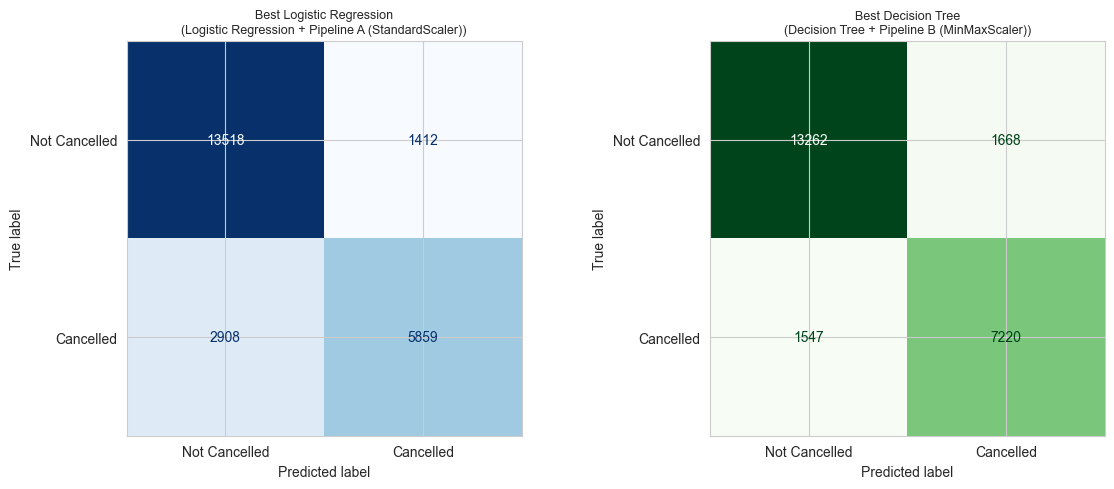

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm_lr = confusion_matrix(y_test, best_lr_clf.predict(X_test))
disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=['Not Cancelled', 'Cancelled'])
disp_lr.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title(f'Best Logistic Regression\n({best_lr_name})', fontsize=9)

cm_dt = confusion_matrix(y_test, best_dt_clf.predict(X_test))
disp_dt = ConfusionMatrixDisplay(confusion_matrix=cm_dt, display_labels=['Not Cancelled', 'Cancelled'])
disp_dt.plot(ax=axes[1], cmap='Greens', colorbar=False)
axes[1].set_title(f'Best Decision Tree\n({best_dt_name})', fontsize=9)

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

In [22]:
# Overfitting check: train vs test accuracy gap for each combination
comparison_table['Train-Test Gap'] = (comparison_table['Train Accuracy'] - comparison_table['Test Accuracy']).round(4)
comparison_table[['Train Accuracy', 'Test Accuracy', 'Train-Test Gap']]

,Train Accuracy,Test Accuracy,Train-Test Gap
Model,,,
Logistic Regression + Pipeline A (StandardScaler),0.8184,0.8177,0.0007
Logistic Regression + Pipeline B (MinMaxScaler),0.8143,0.8150,-0.0007
Decision Tree + Pipeline A (StandardScaler),0.9961,0.8642,0.1319
Decision Tree + Pipeline B (MinMaxScaler),0.9961,0.8643,0.1318


#### Task 6 - Final Observations

In [23]:
print("Full comparison table:\n")
comparison_table[['Train Accuracy', 'Test Accuracy', 'Precision', 'Recall', 'F1-score']]

Full comparison table:



,Train Accuracy,Test Accuracy,Precision,Recall,F1-score
Model,,,,,
Logistic Regression + Pipeline A (StandardScaler),0.8184,0.8177,0.8058,0.6683,0.7306
Logistic Regression + Pipeline B (MinMaxScaler),0.8143,0.8150,0.8048,0.6599,0.7252
Decision Tree + Pipeline A (StandardScaler),0.9961,0.8642,0.8120,0.8234,0.8177
Decision Tree + Pipeline B (MinMaxScaler),0.9961,0.8643,0.8123,0.8235,0.8179


Final Observations

1.Best overall combination: The Decision Tree + Pipeline B (MinMaxScaler) gives the best overall result, with the highest test accuracy (~86.4%) and F1-score (~0.818), very marginally ahead of Decision Tree + Pipeline A. Both Decision Tree runs clearly outperform both Logistic Regression runs on test accuracy, recall, and F1-score.

2.StandardScaler vs MinMaxScaler for Logistic Regression: Scaling choice makes a small but visible difference for Logistic Regression: Pipeline A (StandardScaler) reaches ~81.8% test accuracy and F1 ≈ 0.731, versus Pipeline B (MinMaxScaler) at ~81.5% test accuracy and F1 ≈ 0.725. StandardScaler edges out MinMaxScaler here, which fits expectations since Logistic Regression's gradient-based optimization tends to converge more efficiently on zero-centered, unit-variance features.

3.Effect of scaling on Decision Tree: Scaling has essentially no effect on the Decision Tree — Pipeline A and Pipeline B produce nearly identical test accuracy (86.42% vs 86.43%) and F1-score (0.8177 vs 0.8179). This confirms the expected behavior: trees split on feature thresholds/ordering, not on distances or magnitudes, so StandardScaler vs MinMaxScaler is essentially irrelevant to how the tree partitions the data.

4.Overfitting: The Decision Tree combinations show strong overfitting — training accuracy is ~99.6% for both pipelines while test accuracy drops to ~86.4%, a gap of over 13 points. Logistic Regression shows almost no overfitting, with train and test accuracy nearly identical (~81.8-81.9% vs ~81.5-81.8%). This is expected: the unconstrained Decision Tree grows until it fits the training data almost perfectly (memorizing noise), while the simpler linear Logistic Regression generalizes more consistently. This suggests the Decision Tree would benefit from pruning (e.g. `max_depth`, `min_samples_leaf`) to reduce overfitting.

5.Precision/Recall tradeoff: Both Decision Tree runs have noticeably higher recall (~0.823) than both Logistic Regression runs (~0.66-0.67), meaning the Decision Tree catches more of the actual cancellations, at a similar precision level (~0.81 for both model types). In practical terms, if the goal is to flag as many at-risk cancellations as possible (e.g. for a hotel's overbooking strategy), the Decision Tree is the stronger choice; Logistic Regression is more conservative and misses more true cancellations.